<a href="https://colab.research.google.com/github/Francisco-Alfredo/Fraud-detection-analysis/blob/main/Fraud_Detection_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ============================================================
# 1. Imports e Carregamento dos Dados
# ============================================================

In [19]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="darkgrid", palette="Set2")
plt.rcParams["figure.figsize"] = (12, 6)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
folder = '/content/drive/MyDrive/base de dados/fraud_detection_analysis'

In [22]:
file = os.listdir(folder)
file

['Fraud Detection Dataset.csv']

In [23]:

df = pd.read_csv(os.path.join(folder, file[0]))
df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


# ============================================================
# 2. EDA — Análise Exploratória
# ============================================================

In [24]:
df.describe(include='all')

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
count,51000,51000.000000,48480.000000,51000,48448.000000,48527,48453,51000.000000,51000.000000,51000.000000,48531,51000.000000
unique,50000,NaN,NaN,5,NaN,4,8,NaN,NaN,NaN,5,NaN
top,T49147,NaN,NaN,Bill Payment,NaN,Desktop,Boston,NaN,NaN,NaN,UPI,NaN
freq,2,NaN,NaN,10340,NaN,15795,6149,NaN,NaN,NaN,11887,NaN
mean,NaN,3005.110176,2996.249784,NaN,11.488400,NaN,NaN,1.995725,60.033902,7.495588,NaN,0.049216
std,NaN,1153.121107,5043.932555,NaN,6.922954,NaN,NaN,1.415150,34.384131,4.020080,NaN,0.216320
min,NaN,1000.000000,5.030000,NaN,0.000000,NaN,NaN,0.000000,1.000000,1.000000,NaN,0.000000
25%,NaN,2007.000000,1270.552500,NaN,5.000000,NaN,NaN,1.000000,30.000000,4.000000,NaN,0.000000
50%,NaN,2996.000000,2524.100000,NaN,12.000000,NaN,NaN,2.000000,60.000000,7.000000,NaN,0.000000
75%,NaN,4006.000000,3787.240000,NaN,17.000000,NaN,NaN,3.000000,90.000000,11.000000,NaN,0.000000


In [25]:
#Valores Missing por coluna
df.isna().sum().sort_values(ascending=False)

,0
Time_of_Transaction,2552
Location,2547
Transaction_Amount,2520
Device_Used,2473
Payment_Method,2469
Transaction_Type,0
Transaction_ID,0
User_ID,0
Previous_Fraudulent_Transactions,0
Account_Age,0


-----------------------------------------------------
# Entendendo o desbalanciamento da class
-----------------------------------------------------

In [26]:
df['Fraudulent'].value_counts(normalize=True)

,proportion
Fraudulent,
0,0.950784
1,0.049216


<ol><b>Desbalanceamento da Classe:</b> A saída mostra que aproximadamente 95,08% das transações (0) são não fraudulentas, enquanto apenas 4,92% (1) são fraudulentas.</ol>
<ol><b>Implicação para Modelagem:</b> Este é um exemplo clássico de um conjunto de dados desbalanceado. Em tarefas de detecção de fraude, isso é muito comum, já que transações fraudulentas são, felizmente, a minoria.</ol>
<ol><b>Desafios para o Modelo:</b> Se formos construir um modelo de machine learning para detectar fraudes, ele pode ter dificuldade em aprender a identificar as transações fraudulentas (a classe minoritária), pois a maioria dos exemplos que ele vê são não fraudulentos. Um modelo simples que sempre preveja 'não fraudulento' teria uma precisão aparente de cerca de 95%, mas seria inútil para o propósito de detecção de fraude.</ol>
<ol><b>Próximos Passos:</b> Para lidar com esse desbalanceamento, técnicas como oversampling (ex: SMOTE), undersampling, ajustes de peso de classe ou o uso de métricas de avaliação apropriadas (como Recall, Precision, F1-Score ou AUC-ROC, e não apenas acurácia) serão cruciais nas etapas de modelagem.<ol>

--------------------------------------------------------------------
# Análisando a distribuição dos valores na coluna Transaction_Amount
--------------------------------------------------------------------

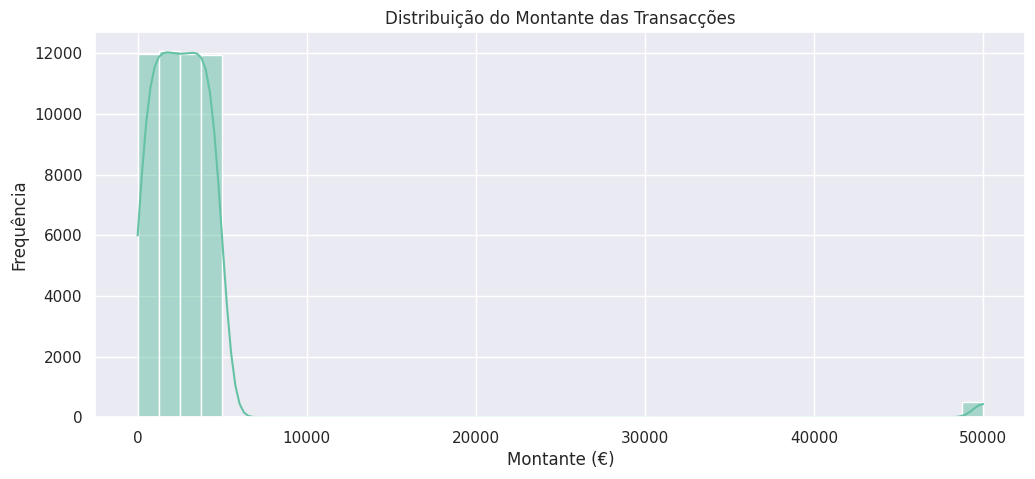

In [27]:
plt.figure(figsize=(12,5))
sns.histplot(df["Transaction_Amount"], bins=40, kde=True)
plt.title("Distribuição do Montante das Transacções")
plt.xlabel("Montante (€)")
plt.ylabel("Frequência")
plt.show()


Text(0.5, 0, 'Montante (€)')

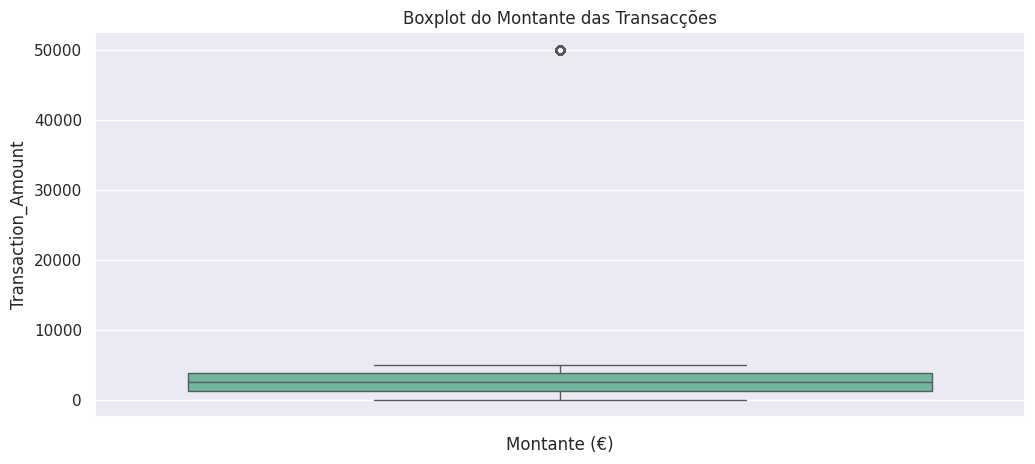

In [28]:
#
plt.figure(figsize=(12,5))
sns.boxplot(df["Transaction_Amount"])
plt.title("Boxplot do Montante das Transacções")
plt.xlabel("Montante (€)")

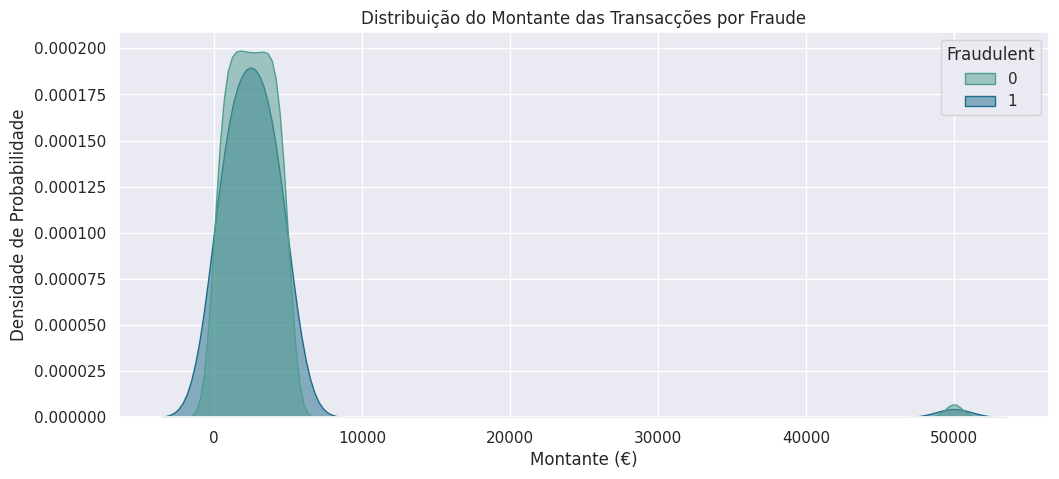

In [29]:
#Distribuição do montante por fraude
plt.figure(figsize=(12,5))
sns.kdeplot(
    data=df,
    x="Transaction_Amount",
    hue="Fraudulent",
    fill=True,
    common_norm=False,
    alpha=.5,
    palette="crest"
)
plt.title("Distribuição do Montante das Transacções por Fraude")
plt.xlabel("Montante (€)")
plt.ylabel("Densidade de Probabilidade")
plt.show()

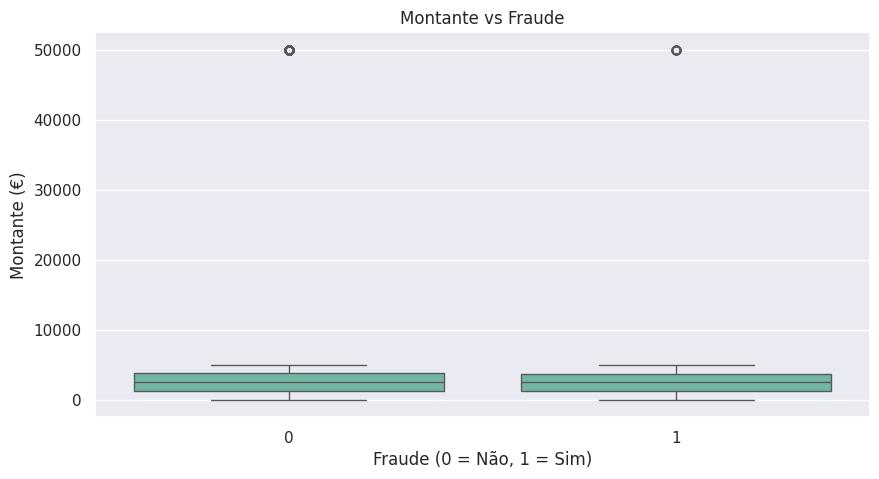

In [30]:
#Montante de Transações por Fraude
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="Fraudulent", y="Transaction_Amount")
plt.title("Montante vs Fraude")
plt.xlabel("Fraude (0 = Não, 1 = Sim)")
plt.ylabel("Montante (€)")
plt.show()


<ol><b>Assimetria Elevada:</b> O histograma e o boxplot mostram claramente que a distribuição de Transaction_Amount é altamente assimétrica à direita. Isso significa que a grande maioria das transações envolve valores menores.</ol>
<ol><b>Outliers e Transações Grandes:</b> Existem outliers significativos, representando transações com valores muito altos, atingindo o máximo de 49997.8. Essas transações grandes são visíveis como a cauda longa no histograma e como pontos individuais além do limite superior no boxplot. Embora possam ser legítimas, em detecção de fraude, tais anomalias frequentemente justificam uma investigação mais aprofundada.</ol>
<ol><b>Concentração em Valores Baixos:</b> A maioria das transações está concentrada na extremidade inferior do espectro, indicando que as transações típicas são de quantias relativamente modestas.</ol>
.<ol><b>Moda no Valor Máximo:</b> Curiosamente, a moda (49997.8) da Transaction_Amount é também o valor máximo. Isso sugere que este valor máximo específico ocorre com mais frequência do que qualquer outro valor de transação individual. Isso pode ser devido a um limite máximo para os valores das transações ou a um tipo específico de transação que frequentemente atinge esse limite superior. Esta é uma característica incomum para uma variável contínua e pode valer a pena explorar mais a fundo.</ol>
<ol><b>Fraude e Montante:</b> Analisando os plots de densidade e boxplot por 'Fraudulent', percebe-se que as transações fraudulentas (1) tendem a ter uma distribuição de montante ligeiramente diferente ou mais dispersa em valores altos, mas também se concentram em valores menores. Isso sugere que tanto transações de pequeno quanto de grande valor podem ser fraudulentas, mas os valores mais altos podem ser mais frequentemente associados à fraude, ou representam um risco maior.</ol>


-----------------------------------------------------
# Distribuição do Tempo(hora) de transação
----------------------------------------------------

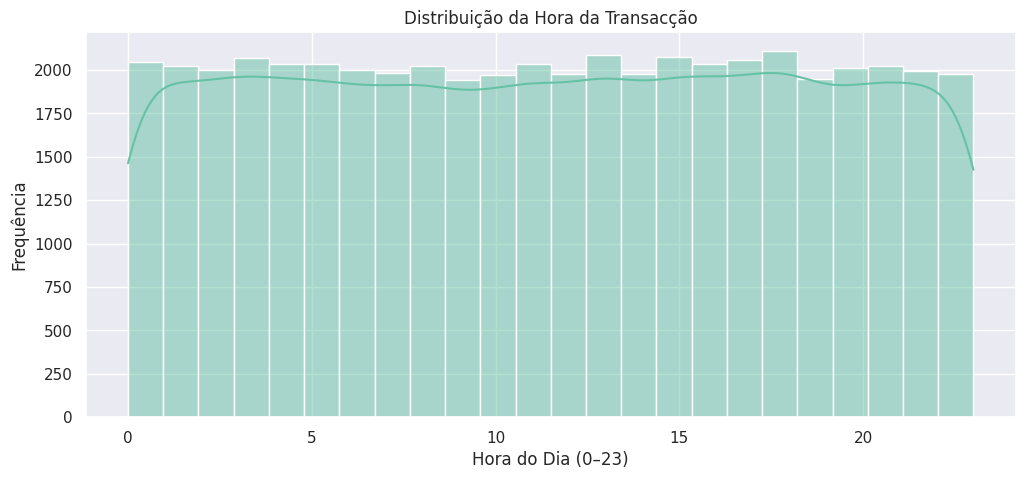

In [31]:
plt.figure(figsize=(12,5))
sns.histplot(df["Time_of_Transaction"], bins=24, kde=True)
plt.title("Distribuição da Hora da Transacção")
plt.xlabel("Hora do Dia (0–23)")
plt.ylabel("Frequência")
plt.show()


Text(0.5, 0, 'Hora do Dia')

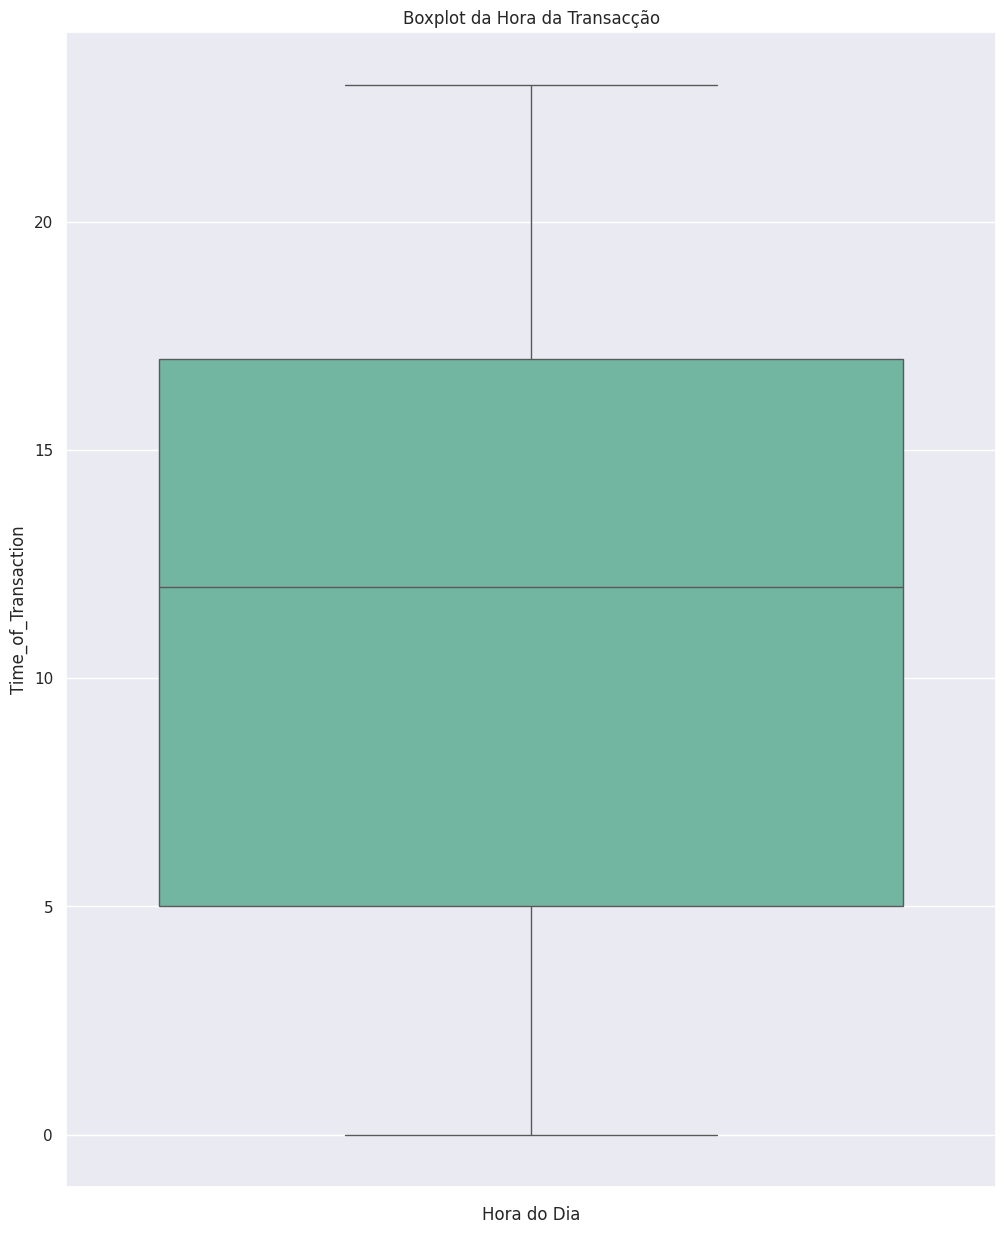

In [32]:
#Detetando outliers
plt.figure(figsize=(12, 15))
sns.boxplot(df["Time_of_Transaction"])
plt.title("Boxplot da Hora da Transacção")
plt.xlabel("Hora do Dia")

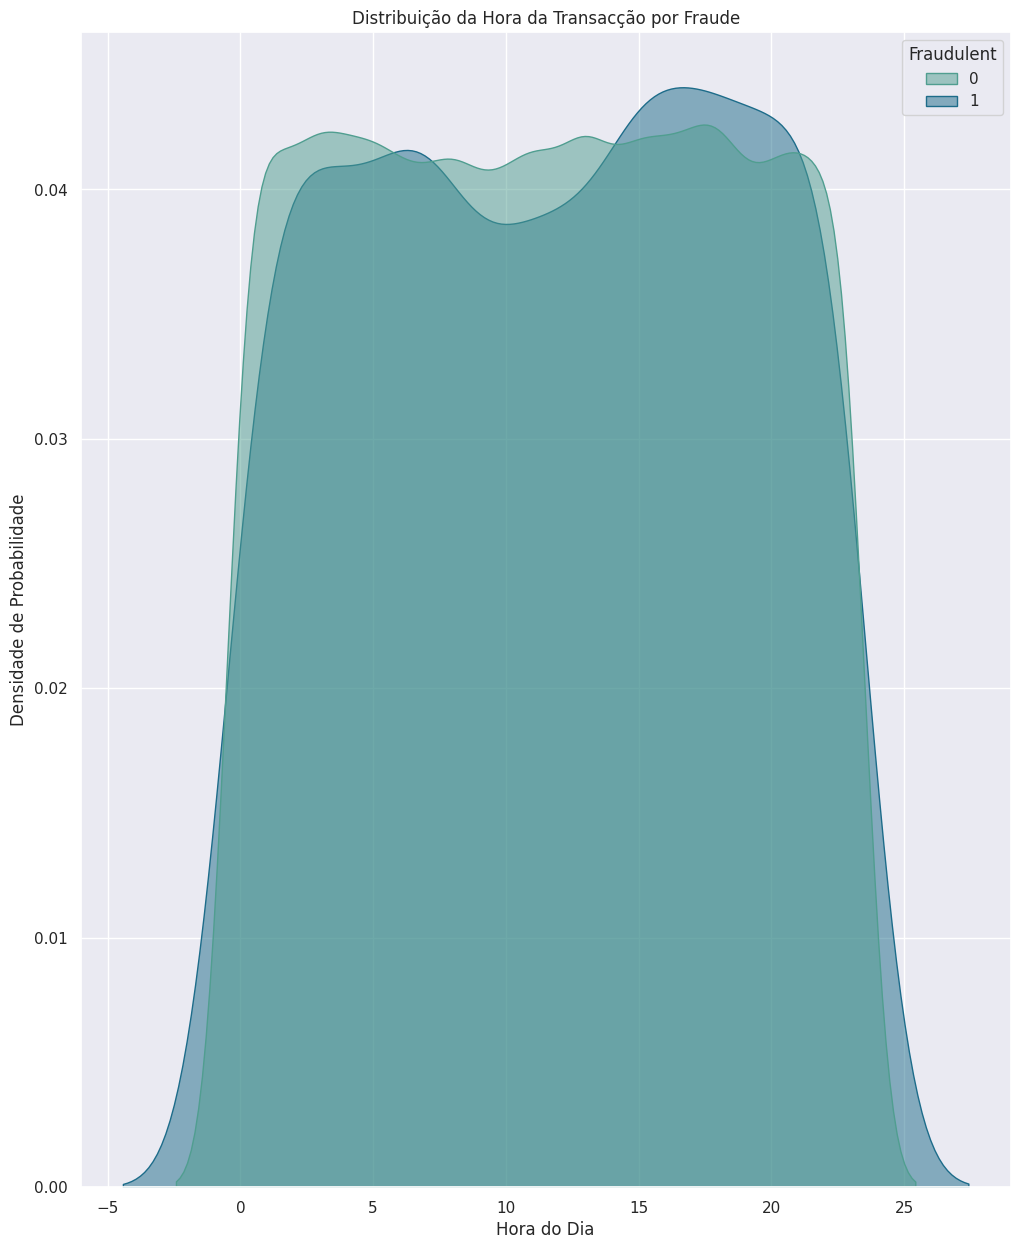

In [33]:
#Tempo de distribuição por Fraude
plt.figure(figsize=(12, 15))
sns.kdeplot(
    data=df,
    x="Time_of_Transaction",
    hue="Fraudulent",
    fill=True,
    common_norm=False,
    alpha=.5,
    palette="crest"
)
plt.title("Distribuição da Hora da Transacção por Fraude")
plt.xlabel("Hora do Dia")
plt.ylabel("Densidade de Probabilidade")
plt.show()

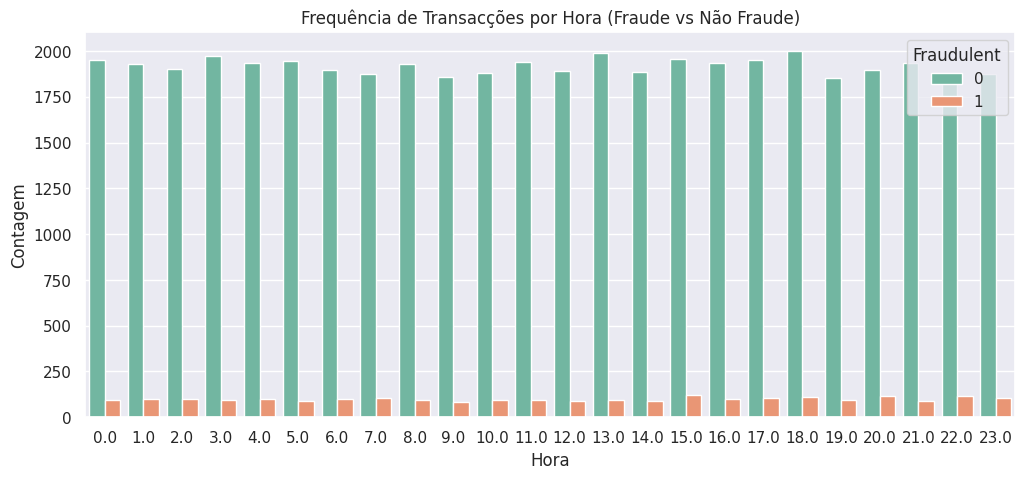

In [34]:
#Frequências de transações absolutas por hora
plt.figure(figsize=(12,5))
sns.countplot(data=df, x="Time_of_Transaction", hue="Fraudulent")
plt.title("Frequência de Transacções por Hora (Fraude vs Não Fraude)")
plt.xlabel("Hora")
plt.ylabel("Contagem")
plt.show()


--------------------------------------------------
# Analisando a distribuição da coluna Account_Age
--------------------------------------------------

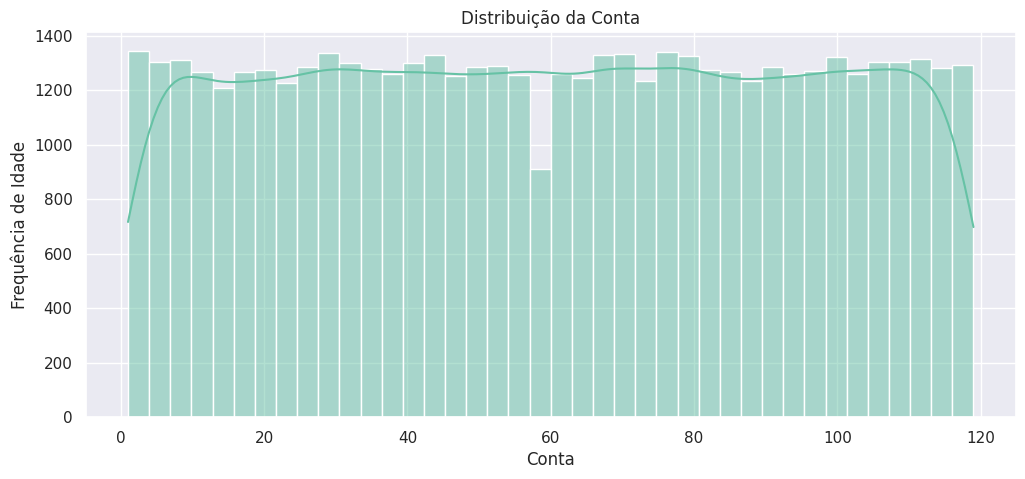

In [35]:
#histogram para ver a distribuição de Account_Age
plt.figure(figsize=(12,5))
sns.histplot(df["Account_Age"], bins=40, kde=True)
plt.title("Distribuição da Conta")
plt.xlabel("Conta")
plt.ylabel("Frequência de Idade")
plt.show()